#### Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score,
                             confusion_matrix, roc_curve)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully.")


All libraries imported successfully.


#### Load and Prepare Data

In [2]:
df = pd.read_csv(r"C:\Users\johny\OneDrive\Desktop\ML\churn-predictor\data\telco_churn_cleaned.csv")

#fix bool columns
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)
#split features and target
X = df.drop(columns=['Churn'])
y=df['Churn']

#Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nBefore SMOTE:")
print(f"Non Churners:{(y_train==0).sum()}")
print(f"Churners:{(y_train==1).sum()}")
print(f"\nOriginal training size: {X_train.shape}")

Training set: (5625, 30)
Testing set: (1407, 30)

Before SMOTE:
Non Churners:4130
Churners:1495

Original training size: (5625, 30)


#### Apply SMOTE
###### We only apply SMOTE on training data — never on test data. Test data must stay real and untouched, otherwise our evaluation is fake.

In [3]:
#Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE:")
print(f"Non Churners:{(y_train_smote==0).sum()}")
print(f"Churners:{(y_train_smote==1).sum()}")
print(f"\n New training size: {X_train_smote.shape}")


After SMOTE:
Non Churners:4130
Churners:4130

 New training size: (8260, 30)


#### Retrain Model on Balanced Data 

In [4]:
# Train logistic regression on SMOTE data
model = LogisticRegression(max_iter=1000)
model.fit(X_train_smote, y_train_smote)

#predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained on balanced data using SMOTE.")
print(f"\nResults after SMOTE:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Model trained on balanced data using SMOTE.

Results after SMOTE:
Accuracy: 0.7619
Precision: 0.5430
Recall: 0.6578
F1 Score: 0.5949
ROC-AUC: 0.8099


#### Plot Confusion Matrix

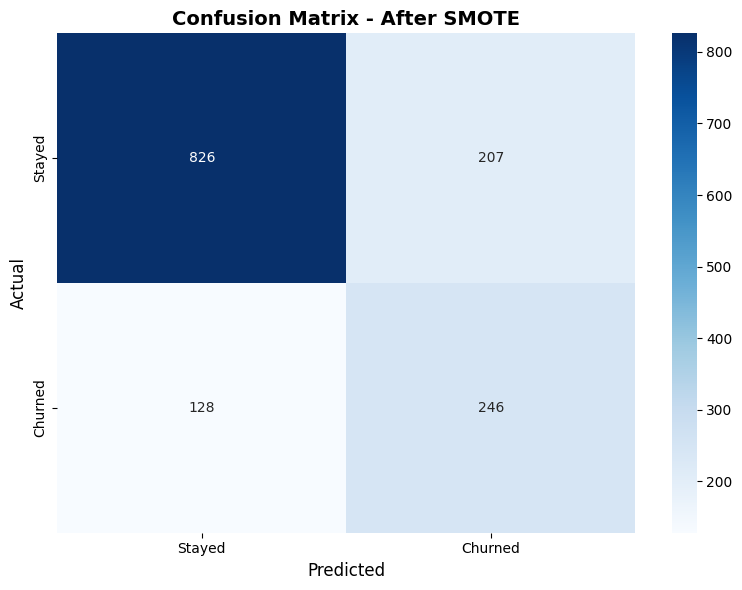

True Negatives  (Correctly predicted Stay):  826
False Positives (Said Churn, actually Stay): 207
False Negatives (Said Stay, actually Churn): 128
True Positives  (Correctly predicted Churn): 246


In [5]:
# Get confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Confusion Matrix - After SMOTE', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()

# Print the numbers clearly
print(f"True Negatives  (Correctly predicted Stay):  {cm[0][0]}")
print(f"False Positives (Said Churn, actually Stay): {cm[0][1]}")
print(f"False Negatives (Said Stay, actually Churn): {cm[1][0]}")
print(f"True Positives  (Correctly predicted Churn): {cm[1][1]}")

#### ROC Curve
###### The ROC Curve plots all these trade-offs in one chart. The bigger the area under the curve, the better the model.


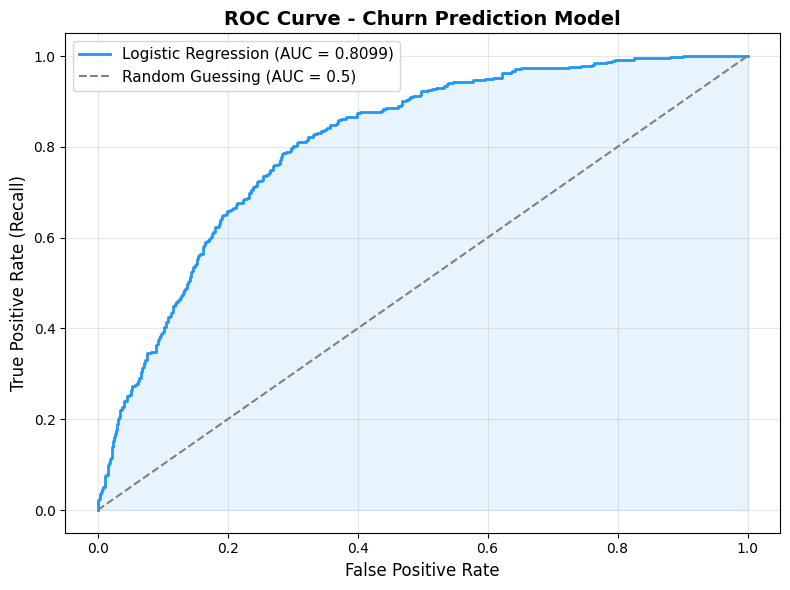

ROC-AUC Score: 0.8099
ROC curve saved!


In [6]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2196F3', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', 
         label='Random Guessing (AUC = 0.5)')

plt.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Churn Prediction Model', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/roc_curve.png', dpi=150)
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")
print("ROC curve saved!")

#### Save the Final Model


In [7]:
# Save the final improved model
joblib.dump(model, '../models/final_model.pkl')
print("✅ Final model saved!")

# Verify it loads correctly
loaded_model = joblib.load('../models/final_model.pkl')
test_pred = loaded_model.predict(X_test)
print(f"✅ Model loaded and verified!")
print(f"✅ Test Accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"✅ Test Recall:   {recall_score(y_test, test_pred):.4f}")
print(f"✅ Test ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")

✅ Final model saved!
✅ Model loaded and verified!
✅ Test Accuracy: 0.7619
✅ Test Recall:   0.6578
✅ Test ROC-AUC:  0.8099
